<a href="https://colab.research.google.com/github/seadawolie/ores5160-202/blob/main/health_data_warehouse_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Mini Health Data Warehouse
## Programming & Governance for Structured Clinical Data

| | |
|---|---|
| **Student** | Seada Wolie |
| **Course** | Data Management and Programming in Healthcare |
| **Dataset** | Synthetic MIMIC-IV–style patient encounter data |
| **Due** | May 12, 2026 |

---

### Pipeline Goals
- ✅ Cleans and reshapes raw data
- ✅ Stores data in structured tables (SQLite star schema)
- ✅ Provides visual feedback on data quality (8 charts)
- ✅ Ensures traceability through clear governance controls


## 0. Setup & Imports

In [1]:
import os, json, logging, sqlite3, warnings, datetime, traceback
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup   # HTML parsing (rubric requirement)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

TIMESTAMP  = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"output_{TIMESTAMP}"
FIG_DIR    = f"{OUTPUT_DIR}/figures"
DB_PATH    = f"{OUTPUT_DIR}/health_warehouse.db"
for d in [OUTPUT_DIR, FIG_DIR]: os.makedirs(d, exist_ok=True)

# Lineage tracker
LINEAGE = []
def track(step, source, rows_in, rows_out, notes=""):
    """Record a lineage event for governance audit trail."""
    LINEAGE.append({"timestamp": datetime.datetime.now().isoformat(),
                    "step": step, "source": source,
                    "rows_in": rows_in, "rows_out": rows_out,
                    "rows_dropped": rows_in - rows_out, "notes": notes})
    print(f"[LINEAGE] {step:<30} | in={rows_in} → out={rows_out} | {notes}")

# Custom exception for data quality failures
class DataQualityError(Exception):
    """Raised when a DataFrame fails a critical quality assertion."""
    pass

print("✅ Setup complete —", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


✅ Setup complete — 2026-05-03 22:53:26


---
## Step 1: Synthetic Data Generation
We generate **4 files** that mimic real open-access MIMIC-IV data:

| File | Format | Content |
|------|--------|---------|
| `patients.csv` | CSV | Demographics, admission dates, LOS |
| `diagnoses.json` | JSON | ICD-10 codes per patient |
| `lab_results.json` | JSON | Lab test results (Hemoglobin, WBC, Creatinine…) |
| `quality_report.html` | HTML | Department-level quality metrics |

**Intentional data quality issues injected:** 8 duplicate patients, 10 negative LOS values, ~5% null severity values.


In [2]:
np.random.seed(42)
N = 300

# ── patients.csv ─────────────────────────────────────────────
dobs   = pd.to_datetime("1940-01-01") + pd.to_timedelta(np.random.randint(0,365*70,N),"D")
admits = pd.to_datetime("2020-01-01") + pd.to_timedelta(np.random.randint(0,365*3,N),"D")
los    = np.round(np.random.exponential(4,N),1)
los[np.random.choice(N,10,replace=False)] = -1  # inject bad LOS

patients_raw = pd.DataFrame({
    "subject_id": range(10000,10000+N),
    "gender": np.random.choice(["M","F","Unknown"],N,p=[0.48,0.48,0.04]),
    "dob": dobs.strftime("%Y-%m-%d"),
    "ethnicity": np.random.choice(["WHITE","BLACK/AFRICAN AMERICAN","HISPANIC/LATINO",
                                    "ASIAN","OTHER",None],N,p=[0.45,0.20,0.15,0.10,0.07,0.03]),
    "admittime": admits.strftime("%Y-%m-%d %H:%M:%S"),
    "los_days": los,
    "insurance": np.random.choice(["Medicare","Medicaid","Private","Self Pay",None],
                                   N,p=[0.35,0.25,0.25,0.10,0.05]),
    "discharge_location": np.random.choice(["HOME","SNF","REHAB","EXPIRED","HOME HEALTH CARE"],
                                            N,p=[0.50,0.20,0.15,0.08,0.07]),
    "hospital_id": np.random.choice(["HOSP_A","HOSP_B","HOSP_C"],N),
})
patients_raw = pd.concat([patients_raw, patients_raw.sample(8,random_state=1)],ignore_index=True)
patients_raw.to_csv(f"{OUTPUT_DIR}/patients.csv", index=False)
print(f"✅ patients.csv: {len(patients_raw)} rows (8 duplicates injected)")

# ── diagnoses.json ───────────────────────────────────────────
ICD = [("I50.9","Heart Failure"),("J18.9","Pneumonia"),("N39.0","UTI"),
       ("E11.9","Type 2 Diabetes"),("I10","Hypertension"),("K92.1","GI Bleed"),
       ("Z79.899","Long-term Drug Use"),("A41.9","Sepsis"),("S72.001A","Hip Fracture"),
       ("F32.9","Depression"),("G30.9","Alzheimer's Disease"),("C34.10","Lung Cancer")]
n_dx = 600
sidx = np.random.choice(patients_raw["subject_id"].unique(), n_dx)
didx = np.random.randint(0,len(ICD),n_dx)
sevs = np.random.choice(["mild","moderate","severe",None],n_dx,p=[0.30,0.40,0.25,0.05])
diagnoses = [{"subject_id":int(sidx[i]),"icd_code":ICD[didx[i]][0],
              "icd_description":ICD[didx[i]][1],"seq_num":int(np.random.randint(1,6)),
              "severity":sevs[i],"diagnosed_date":(pd.to_datetime("2020-01-01")+
              pd.Timedelta(days=int(np.random.randint(0,900)))).strftime("%Y-%m-%d")}
             for i in range(n_dx)]
with open(f"{OUTPUT_DIR}/diagnoses.json","w") as f: json.dump(diagnoses,f,indent=2)
print(f"✅ diagnoses.json: {n_dx} records")

# ── lab_results.json ─────────────────────────────────────────
LABS = [("Hemoglobin","g/dL",12.0,17.5,7.0,20.0),("WBC","K/uL",4.5,11.0,1.0,30.0),
        ("Creatinine","mg/dL",0.6,1.2,0.3,10.0),("Glucose","mg/dL",70.0,100.0,40.0,500.0),
        ("Sodium","mEq/L",136.0,145.0,120.0,160.0),("Potassium","mEq/L",3.5,5.0,2.5,7.0)]
n_lab = 900
lab_sidx = np.random.choice(patients_raw["subject_id"].unique(),n_lab)
lab_idx  = np.random.randint(0,len(LABS),n_lab)
lab_vals = []
for i in range(n_lab):
    nm,unit,lo,hi,vlo,vhi = LABS[lab_idx[i]]
    val = round(np.random.uniform(vlo,vhi),2)
    lab_vals.append({"subject_id":int(lab_sidx[i]),"test_name":nm,"result_value":val,
                     "unit":unit,"normal_low":lo,"normal_high":hi,
                     "flag":"normal" if lo<=val<=hi else ("low" if val<lo else "high"),
                     "collected_date":(pd.to_datetime("2020-01-01")+
                     pd.Timedelta(days=int(np.random.randint(0,900)))).strftime("%Y-%m-%d")})
with open(f"{OUTPUT_DIR}/lab_results.json","w") as f: json.dump(lab_vals,f,indent=2)
print(f"✅ lab_results.json: {n_lab} records")

# ── quality_report.html ──────────────────────────────────────
dept_df = pd.DataFrame({"Department":["ICU","ED","MED/SURG","CARDIOLOGY","ONCOLOGY"],
                         "Encounters":[120,340,280,95,60],"Avg_LOS":[6.2,0.5,3.8,4.1,7.9],
                         "Missing_Pct":[2.1,8.4,5.2,3.0,1.5],"Readmit_30d":[12,28,19,9,7],
                         "Mortality_Pct":[4.2,1.1,0.9,2.3,8.7]})
with open(f"{OUTPUT_DIR}/quality_report.html","w") as f:
    f.write(f"<html><body><h1>Hospital Quality Report</h1>{dept_df.to_html(index=False)}</body></html>")
print("✅ quality_report.html written")
print(f"\n📁 All files in: {OUTPUT_DIR}/")


✅ patients.csv: 308 rows (8 duplicates injected)
✅ diagnoses.json: 600 records
✅ lab_results.json: 900 records
✅ quality_report.html written

📁 All files in: output_20260503_225326/


---
## Step 2: Data Ingestion & File Parsing
Three different ingestion functions — one per format, using the correct module for each.


In [3]:
def ingest_csv(filepath):
    """Load CSV with UTF-8 encoding fallback to latin-1. Tracks lineage."""
    try:
        df = pd.read_csv(filepath, encoding="utf-8")
    except UnicodeDecodeError:
        print("  UTF-8 failed, retrying latin-1")
        df = pd.read_csv(filepath, encoding="latin-1")
    except Exception as e:
        raise RuntimeError(f"CSV ingestion failed: {e}") from e
    track("ingest_csv", filepath, len(df), len(df), "Raw CSV load")
    print(f"  CSV loaded: {df.shape[0]} rows × {df.shape[1]} cols")
    return df

def ingest_json(filepath):
    """Load a JSON list-of-records file into a DataFrame."""
    try:
        with open(filepath,"r") as f: data = json.load(f)
        df = pd.DataFrame(data) if isinstance(data,list) else pd.DataFrame([data])
    except json.JSONDecodeError as e:
        raise RuntimeError(f"JSON parse error: {e}") from e
    track("ingest_json", filepath, len(df), len(df), "Raw JSON load")
    print(f"  JSON loaded: {df.shape[0]} rows × {df.shape[1]} cols")
    return df

def ingest_html(filepath):
    """Parse HTML table via pandas.read_html + BeautifulSoup cross-check."""
    tables = pd.read_html(filepath)
    if not tables: raise ValueError("No tables found in HTML")
    df = tables[0]
    # Cross-check with BeautifulSoup
    with open(filepath,"r") as f:
        soup = BeautifulSoup(f.read(), "html.parser")
    bs_count = len(soup.find_all("table"))
    print(f"  HTML: {df.shape[0]} rows × {df.shape[1]} cols | BeautifulSoup found {bs_count} table(s)")
    track("ingest_html", filepath, len(df), len(df), "HTML parse — pandas + BS4")
    return df

# ── Run ingestion ───────────────────────────────────────────────
raw_patients  = ingest_csv(f"{OUTPUT_DIR}/patients.csv")
raw_diagnoses = ingest_json(f"{OUTPUT_DIR}/diagnoses.json")
raw_lab       = ingest_json(f"{OUTPUT_DIR}/lab_results.json")
raw_dept      = ingest_html(f"{OUTPUT_DIR}/quality_report.html")
print("\n✅ All files ingested successfully")


[LINEAGE] ingest_csv                     | in=308 → out=308 | Raw CSV load
  CSV loaded: 308 rows × 9 cols
[LINEAGE] ingest_json                    | in=600 → out=600 | Raw JSON load
  JSON loaded: 600 rows × 6 cols
[LINEAGE] ingest_json                    | in=900 → out=900 | Raw JSON load
  JSON loaded: 900 rows × 8 cols
  HTML: 5 rows × 6 cols | BeautifulSoup found 1 table(s)
[LINEAGE] ingest_html                    | in=5 → out=5 | HTML parse — pandas + BS4

✅ All files ingested successfully


---
## Step 3: Cleaning, Transformation & Validation
Custom validation checks for missingness, outliers, duplicates, and logical errors.
Exception handling with descriptive error logging throughout.


In [4]:
def assert_columns(df, required, name):
    """Assert all required columns exist. Raises DataQualityError if not."""
    missing = [c for c in required if c not in df.columns]
    if missing: raise DataQualityError(f"[{name}] Missing columns: {missing}")
    print(f"  ✓ Column check passed: {name}")

def clean_patients(df):
    """
    Clean patients DataFrame:
    1. Assert required columns (raises DataQualityError on failure)
    2. Remove duplicate subject_id rows
    3. Cast dob, admittime to datetime
    4. Invalidate negative LOS → NaN; flag IQR outliers
    5. Standardize gender to {M, F, UNKNOWN}
    6. Derive age_at_admit; invalidate impossible values
    7. Impute missing insurance and ethnicity
    8. Add pipeline metadata columns
    """
    n_in = len(df)
    assert_columns(df, ["subject_id","gender","dob","admittime","los_days"], "patients")

    df = df.drop_duplicates(subset=["subject_id"]).copy()
    print(f"  Duplicates removed: {n_in - len(df)}")

    for col in ["dob","admittime"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    bad_los = (df["los_days"] < 0).sum()
    df.loc[df["los_days"]<0,"los_days"] = np.nan
    print(f"  Invalid LOS (negative) → NaN: {bad_los}")

    Q1,Q3 = df["los_days"].quantile([0.25,0.75])
    IQR = Q3-Q1
    df["los_outlier_flag"] = ((df["los_days"]<Q1-3*IQR)|(df["los_days"]>Q3+3*IQR)).astype(int)
    print(f"  LOS IQR outliers flagged: {df['los_outlier_flag'].sum()}")

    df["gender"] = df["gender"].str.upper().str.strip()
    df.loc[~df["gender"].isin(["M","F"]),"gender"] = "UNKNOWN"

    df["age_at_admit"] = ((df["admittime"]-df["dob"]).dt.days/365.25).round(1)
    df.loc[(df["age_at_admit"]<0)|(df["age_at_admit"]>120),"age_at_admit"] = np.nan

    df["insurance"] = df["insurance"].fillna("Unknown")
    df["ethnicity"]  = df["ethnicity"].fillna("NOT DOCUMENTED")
    df["pipeline_version"] = "2.0"

    track("clean_patients","patients.csv",n_in,len(df),"Dedup|cast|LOS validate|IQR flag|age|impute")
    print(f"  ✓ Patients: {n_in} → {len(df)} rows")
    return df

def clean_diagnoses(df):
    """
    Clean diagnoses DataFrame:
    1. Assert required columns
    2. Drop rows missing subject_id or icd_code
    3. Validate ICD-10 format via regex
    4. Cast diagnosed_date; fill null severity
    5. Deduplicate on (subject_id, icd_code, seq_num)
    """
    n_in = len(df)
    assert_columns(df, ["subject_id","icd_code","icd_description","seq_num"], "diagnoses")

    df = df.dropna(subset=["subject_id","icd_code"]).copy()
    df["icd_valid"] = df["icd_code"].str.match(r"^[A-Z]\d{2}(\.\d+)?[A-Z]?$", na=False)
    n_invalid = (~df["icd_valid"]).sum()
    if n_invalid: print(f"  ⚠ ICD codes with unexpected format (flagged): {n_invalid}")

    df["diagnosed_date"] = pd.to_datetime(df["diagnosed_date"], errors="coerce")
    n_null = df["severity"].isna().sum()
    df["severity"] = df["severity"].fillna("unknown")
    print(f"  Severity nulls imputed: {n_null}")

    before = len(df)
    df = df.drop_duplicates(subset=["subject_id","icd_code","seq_num"])
    print(f"  Duplicates removed: {before-len(df)}")

    track("clean_diagnoses","diagnoses.json",n_in,len(df),"Null drop|ICD validate|cast|dedup")
    print(f"  ✓ Diagnoses: {n_in} → {len(df)} rows")
    return df

def clean_lab(df):
    """
    Clean lab results DataFrame:
    1. Assert required columns
    2. Cast result_value to float, collected_date to datetime
    3. Recompute flag from result vs normal range
    4. Flag extreme outliers using Z-score (|Z| > 3)
    """
    n_in = len(df)
    assert_columns(df, ["subject_id","test_name","result_value","unit"], "lab_results")

    df = df.dropna(subset=["subject_id","test_name"]).copy()
    df["result_value"]   = pd.to_numeric(df["result_value"], errors="coerce")
    df["collected_date"] = pd.to_datetime(df["collected_date"], errors="coerce")

    df["flag"] = "normal"
    df.loc[df["result_value"] < df["normal_low"],  "flag"] = "low"
    df.loc[df["result_value"] > df["normal_high"], "flag"] = "high"
    df.loc[df["result_value"].isna(),              "flag"] = "missing"

    df["z_score"] = df.groupby("test_name")["result_value"].transform(
        lambda x: (x - x.mean()) / x.std()).round(3)
    df["extreme_outlier"] = (df["z_score"].abs() > 3).astype(int)
    print(f"  Extreme outliers flagged (|Z|>3): {df['extreme_outlier'].sum()}")

    track("clean_lab","lab_results.json",n_in,len(df),"Cast|flag recompute|Z-score outlier")
    print(f"  ✓ Lab results: {n_in} → {len(df)} rows")
    return df

def validate_df(df, name, required_cols):
    """
    Run comprehensive validation suite:
    - Required columns check
    - Missing value % per column
    - Duplicate row count
    - IQR outlier detection on numeric columns
    Returns a structured quality report dict.
    """
    report = {"table":name, "rows":len(df), "issues":[], "outliers":{}}
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols: report["issues"].append(f"Missing columns: {missing_cols}")
    null_pct = (df.isnull().sum()/len(df)*100).round(2)
    report["null_pct"] = null_pct.to_dict()
    high_null = null_pct[null_pct>10]
    if not high_null.empty: report["issues"].append(f"High null% >10: {high_null.to_dict()}")
    n_dupes = df.duplicated().sum()
    if n_dupes: report["issues"].append(f"{n_dupes} duplicate rows")
    for col in df.select_dtypes(include=np.number).columns:
        Q1,Q3 = df[col].quantile([.25,.75]); IQR=Q3-Q1
        n = int(((df[col]<Q1-3*IQR)|(df[col]>Q3+3*IQR)).sum())
        if n: report["outliers"][col]=n
    print(f"  [{name}] {len(report['issues'])} issue(s) | outlier cols: {list(report['outliers'].keys())}")
    return report

# ── Run cleaning ───────────────────────────────────────────────
print("=== Cleaning ===")
patients_clean  = clean_patients(raw_patients)
diagnoses_clean = clean_diagnoses(raw_diagnoses)
lab_clean       = clean_lab(raw_lab)

print("\n=== Validation ===")
val_p = validate_df(patients_clean,  "patients",  ["subject_id","gender","dob","admittime","los_days"])
val_d = validate_df(diagnoses_clean, "diagnoses", ["subject_id","icd_code","icd_description","seq_num"])
val_l = validate_df(lab_clean,       "lab_results",["subject_id","test_name","result_value","flag"])
print("\n✅ Cleaning & validation complete")


=== Cleaning ===
  ✓ Column check passed: patients
  Duplicates removed: 8
  Invalid LOS (negative) → NaN: 10
  LOS IQR outliers flagged: 2
[LINEAGE] clean_patients                 | in=308 → out=300 | Dedup|cast|LOS validate|IQR flag|age|impute
  ✓ Patients: 308 → 300 rows
  ✓ Column check passed: diagnoses
  Severity nulls imputed: 25
  Duplicates removed: 11
[LINEAGE] clean_diagnoses                | in=600 → out=589 | Null drop|ICD validate|cast|dedup
  ✓ Diagnoses: 600 → 589 rows
  ✓ Column check passed: lab_results
  Extreme outliers flagged (|Z|>3): 0
[LINEAGE] clean_lab                      | in=900 → out=900 | Cast|flag recompute|Z-score outlier
  ✓ Lab results: 900 → 900 rows

=== Validation ===
  [patients] 0 issue(s) | outlier cols: ['los_days', 'los_outlier_flag']
  [diagnoses] 0 issue(s) | outlier cols: []
  [lab_results] 0 issue(s) | outlier cols: ['result_value']

✅ Cleaning & validation complete


---
## Step 4: Reshaping & Integration

In [5]:
# 1. Merge patients ← diagnoses (one-to-many left join)
enc = pd.merge(patients_clean,
               diagnoses_clean[["subject_id","icd_code","icd_description","severity","seq_num","icd_valid"]],
               on="subject_id", how="left")
print(f"patients ← diagnoses (left join): {enc.shape}")
track("merge_patients_diagnoses","patients+diagnoses",len(patients_clean),len(enc),"Left join on subject_id")

# 2. Pivot lab results: first result per patient per test
lab_first = (lab_clean.sort_values("collected_date")
                       .drop_duplicates(subset=["subject_id","test_name"])
                       [["subject_id","test_name","result_value"]])
lab_pivot = lab_first.pivot(index="subject_id", columns="test_name", values="result_value").reset_index()
lab_pivot.columns = ["subject_id"] + [f"lab_{c.lower()}" for c in lab_pivot.columns[1:]]
full_enc = pd.merge(enc, lab_pivot, on="subject_id", how="left")
print(f"encounters ← lab pivot (left join): {full_enc.shape}")

# 3. Pivot: severity counts per patient (unstack)
sev_pivot = (diagnoses_clean.groupby(["subject_id","severity"]).size()
             .unstack(fill_value=0).reset_index())
print(f"Severity pivot: {sev_pivot.shape}")
display(sev_pivot.head(3))

# 4. Melt dept data to long form
dept_long = raw_dept.melt(id_vars=["Department"],
                           value_vars=["Encounters","Avg_LOS","Missing_Pct","Readmit_30d","Mortality_Pct"],
                           var_name="Metric", value_name="Value")
print(f"Dept long form: {dept_long.shape}")

# 5. Lab summary: abnormality rates per test
lab_summary = (lab_clean.groupby("test_name")
               .agg(total=("result_value","count"),
                    pct_abnormal=("flag",lambda x: round((x!="normal").mean()*100,1)),
                    mean_value=("result_value","mean"),
                    std_value=("result_value","std"))
               .reset_index())
print(f"Lab summary: {lab_summary.shape}")
display(lab_summary)
print("\n✅ Reshaping & integration complete")


patients ← diagnoses (left join): (628, 17)
[LINEAGE] merge_patients_diagnoses       | in=300 → out=628 | Left join on subject_id
encounters ← lab pivot (left join): (628, 23)
Severity pivot: (261, 5)


severity,subject_id,mild,moderate,severe,unknown
0,10000,0,1,0,0
1,10002,0,2,0,0
2,10003,0,2,0,0


Dept long form: (25, 3)
Lab summary: (6, 5)


,test_name,total,pct_abnormal,mean_value,std_value
0,Creatinine,144,93.1,5.378819,2.802842
1,Glucose,126,93.7,258.763175,127.750410
2,Hemoglobin,149,61.7,13.385436,3.927133
3,Potassium,137,71.5,4.778978,1.357542
4,Sodium,161,71.4,140.230186,10.937276
5,WBC,183,76.0,14.734044,8.546830



✅ Reshaping & integration complete


---
## Step 5: SQL Relational Storage — SQLite Star Schema

**Schema design:** `dim_patients` and `dim_departments` (dimensions) linked to `fact_diagnoses`, `fact_lab_results`, and `fact_encounters` (facts).

In [6]:
def prep(df):
    """Serialize datetime columns to strings for SQLite compatibility."""
    df = df.copy()
    for col in df.select_dtypes(include=["datetime64[ns]"]).columns:
        df[col] = df[col].astype(str)
    return df

conn = sqlite3.connect(DB_PATH)
tables = {
    "dim_patients"    : patients_clean,
    "dim_departments" : raw_dept,
    "fact_diagnoses"  : diagnoses_clean,
    "fact_lab_results": lab_clean,
    "fact_encounters" : full_enc,
}
for tbl, df in tables.items():
    prep(df).to_sql(tbl, conn, if_exists="replace", index=False)
    print(f"  ✓ {tbl:<22}: {len(df):>6} rows")

# SQL verification query
cursor = conn.cursor()
sql = ("SELECT p.subject_id, p.gender, p.age_at_admit, COUNT(d.icd_code) AS dx_count "
       "FROM dim_patients p "
       "LEFT JOIN fact_diagnoses d ON p.subject_id = d.subject_id "
       "GROUP BY p.subject_id LIMIT 5")
cursor.execute(sql)
print("\nSQL verification — patient + diagnosis counts:")
for row in cursor.fetchall():
    print(f"  subject_id={row[0]} | gender={row[1]} | age={row[2]} | diagnoses={row[3]}")
conn.close()

# CSV copies
for tbl, df in tables.items():
    prep(df).to_csv(f"{OUTPUT_DIR}/{tbl}.csv", index=False)
print(f"\n✅ SQLite DB saved: {DB_PATH}")
print(f"✅ CSV copies saved to {OUTPUT_DIR}/")


  ✓ dim_patients          :    300 rows
  ✓ dim_departments       :      5 rows
  ✓ fact_diagnoses        :    589 rows
  ✓ fact_lab_results      :    900 rows
  ✓ fact_encounters       :    628 rows

SQL verification — patient + diagnosis counts:
  subject_id=10000 | gender=F | age=18.0 | diagnoses=1
  subject_id=10001 | gender=F | age=36.8 | diagnoses=0
  subject_id=10002 | gender=F | age=79.9 | diagnoses=2
  subject_id=10003 | gender=F | age=65.8 | diagnoses=2
  subject_id=10004 | gender=UNKNOWN | age=22.0 | diagnoses=3

✅ SQLite DB saved: output_20260503_225326/health_warehouse.db
✅ CSV copies saved to output_20260503_225326/


---
## Step 6: Visualizations
8 charts covering EDA and data quality.

### Age Distribution

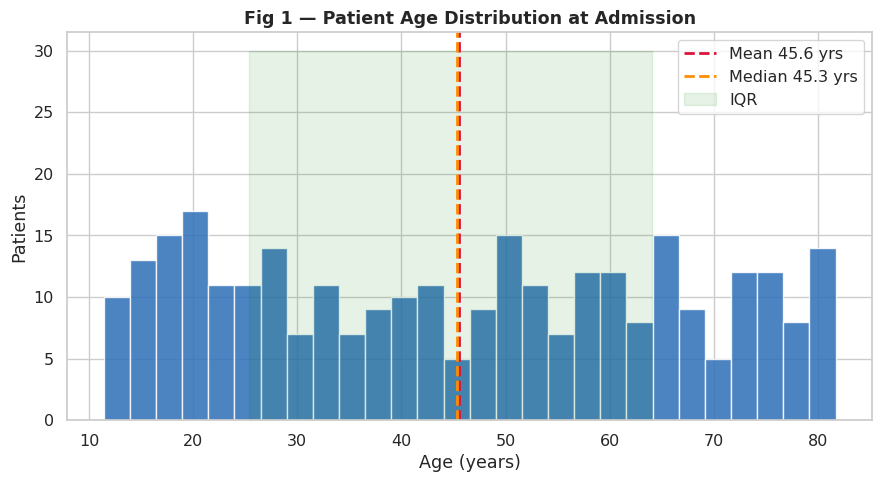

In [7]:

ages = patients_clean["age_at_admit"].dropna()
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(ages, bins=28, color="#2d6eb8", edgecolor="white", alpha=0.85)
ax.axvline(ages.mean(),   color="crimson",     lw=2, ls="--", label=f"Mean {ages.mean():.1f} yrs")
ax.axvline(ages.median(), color="darkorange",  lw=2, ls="--", label=f"Median {ages.median():.1f} yrs")
ax.fill_betweenx([0,30], ages.quantile(0.25), ages.quantile(0.75), alpha=0.10, color="green", label="IQR")
ax.set_title("Fig 1 — Patient Age Distribution at Admission", fontweight="bold")
ax.set_xlabel("Age (years)"); ax.set_ylabel("Patients"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig1_age.png",dpi=150); plt.show()


### LOS Boxplot

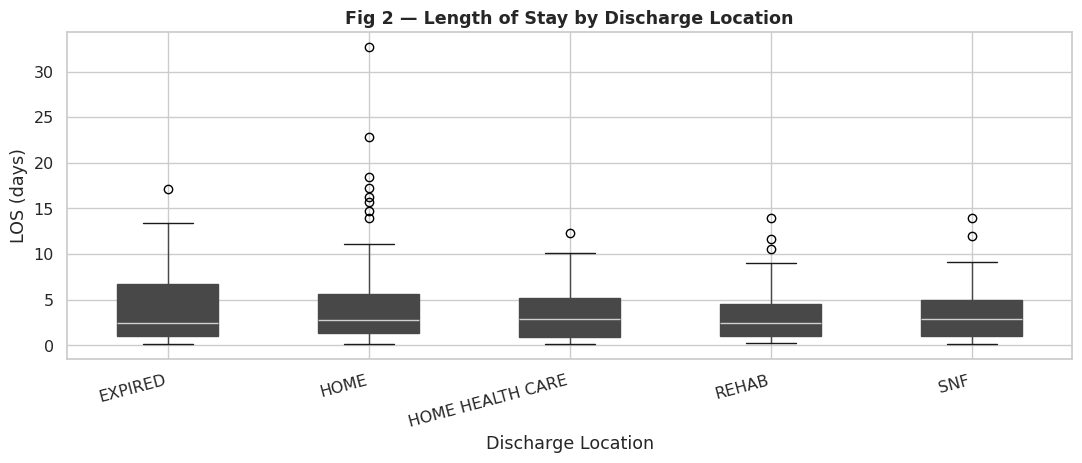

In [8]:

fig, ax = plt.subplots(figsize=(11,5))
patients_clean.boxplot(column="los_days", by="discharge_location", ax=ax, patch_artist=True)
ax.set_title("Fig 2 — Length of Stay by Discharge Location", fontweight="bold")
ax.set_xlabel("Discharge Location"); ax.set_ylabel("LOS (days)"); plt.suptitle("")
plt.xticks(rotation=15,ha="right"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_los.png",dpi=150); plt.show()


### Top 10 Diagnoses

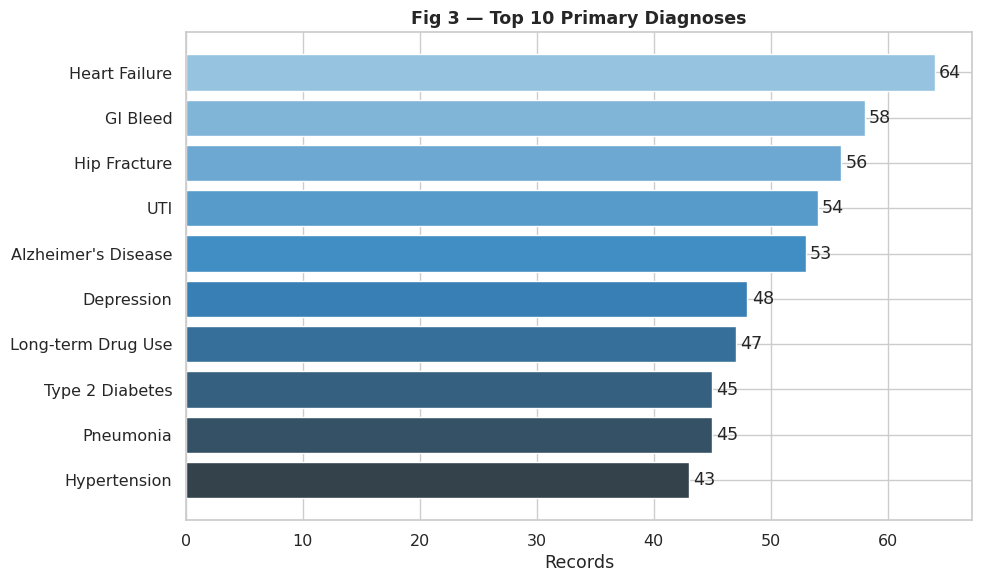

In [9]:

top = diagnoses_clean["icd_description"].value_counts().head(10).reset_index()
top.columns = ["Diagnosis","Count"]
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(top["Diagnosis"], top["Count"], color=sns.color_palette("Blues_d",len(top)))
ax.bar_label(bars, padding=3); ax.invert_yaxis()
ax.set_title("Fig 3 — Top 10 Primary Diagnoses", fontweight="bold"); ax.set_xlabel("Records")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig3_dx.png",dpi=150); plt.show()


### Missing Data Heatmap

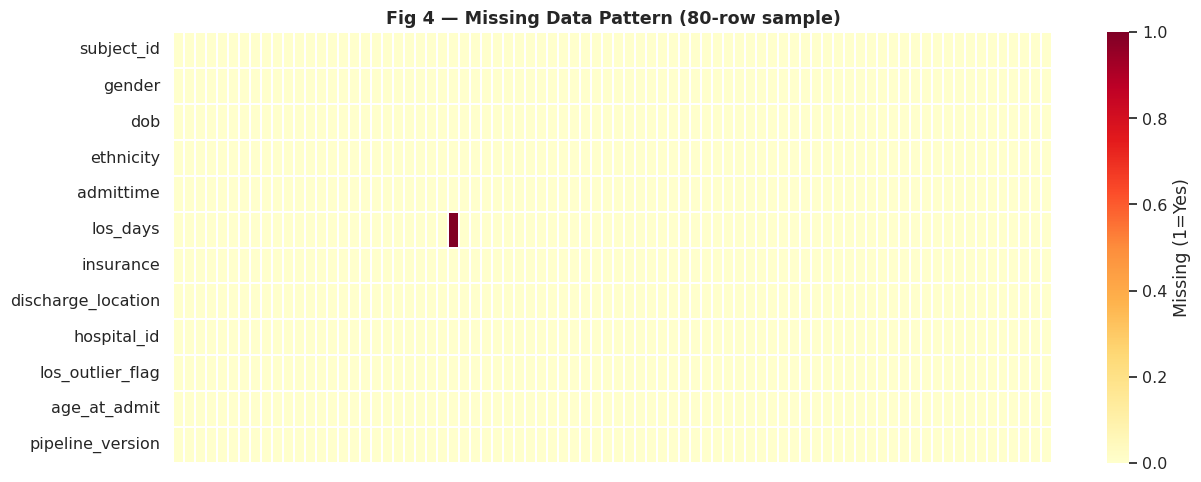

In [10]:

fig, ax = plt.subplots(figsize=(13,5))
sample = patients_clean.isnull().astype(int).sample(min(80,len(patients_clean)),random_state=42)
sns.heatmap(sample.T, cmap="YlOrRd", cbar=True, cbar_kws={"label":"Missing (1=Yes)"},
            ax=ax, xticklabels=False, linewidths=0.2)
ax.set_title("Fig 4 — Missing Data Pattern (80-row sample)", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig4_missing.png",dpi=150); plt.show()


### Departmental Dashboard

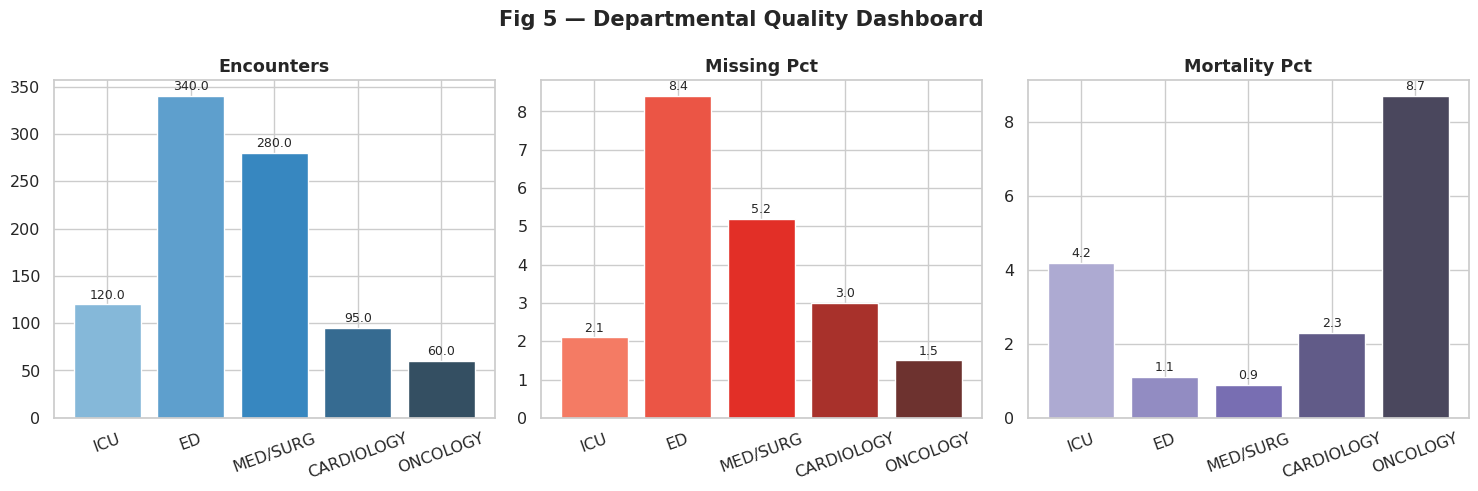

In [11]:

fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax, metric, pal in zip(axes,["Encounters","Missing_Pct","Mortality_Pct"],["Blues_d","Reds_d","Purples_d"]):
    sub = dept_long[dept_long["Metric"]==metric]
    bars = ax.bar(sub["Department"],sub["Value"],color=sns.color_palette(pal,len(sub)))
    ax.bar_label(bars,fmt="%.1f",padding=2,fontsize=9)
    ax.set_title(metric.replace("_"," "),fontweight="bold"); ax.tick_params(axis="x",rotation=20)
plt.suptitle("Fig 5 — Departmental Quality Dashboard", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig5_dept.png",dpi=150); plt.show()


### Severity Pie

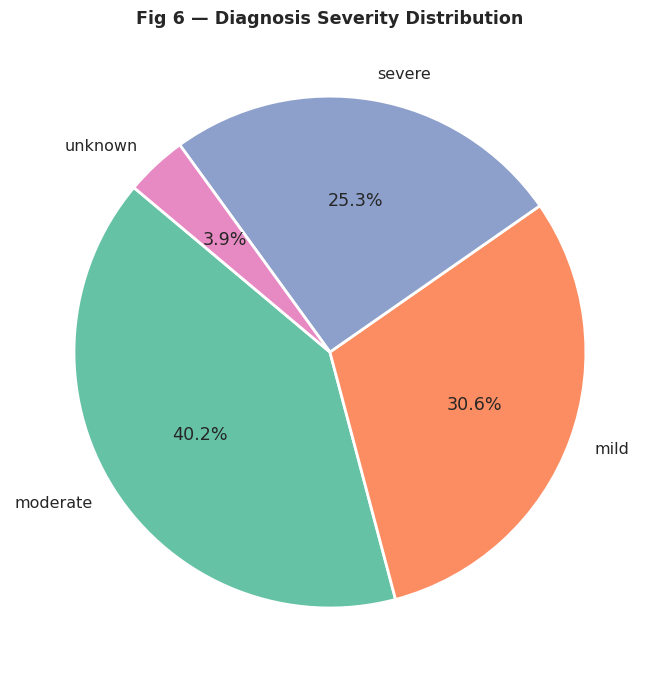

In [12]:

sev = diagnoses_clean["severity"].value_counts()
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(sev, labels=sev.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"),
       startangle=140, wedgeprops={"edgecolor":"white","linewidth":2})
ax.set_title("Fig 6 — Diagnosis Severity Distribution", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig6_severity.png",dpi=150); plt.show()


### Lab Abnormality Rates

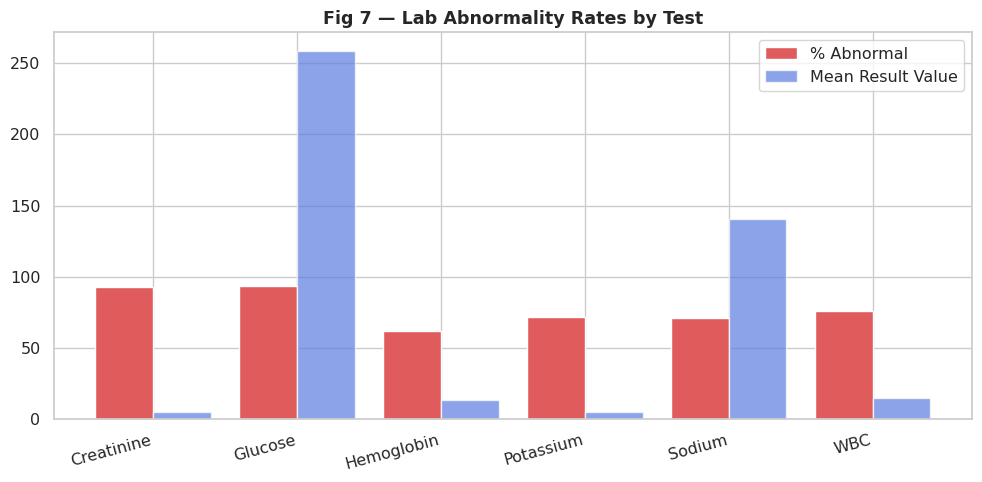

In [13]:

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(lab_summary)); w=0.4
ax.bar(x-w/2, lab_summary["pct_abnormal"], w, label="% Abnormal",       color="#e05c5c")
ax.bar(x+w/2, lab_summary["mean_value"],   w, label="Mean Result Value", color="#5c7de0", alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(lab_summary["test_name"],rotation=15,ha="right")
ax.set_title("Fig 7 — Lab Abnormality Rates by Test", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig7_lab.png",dpi=150); plt.show()


### Insurance & Readmission

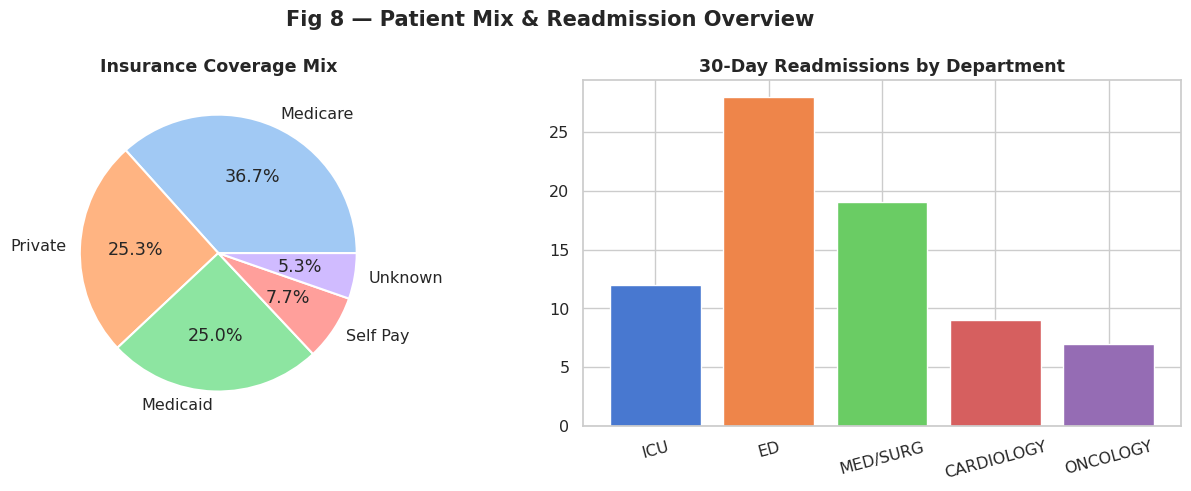

In [14]:

fig, axes = plt.subplots(1,2,figsize=(13,5))
ins = patients_clean["insurance"].value_counts()
axes[0].pie(ins, labels=ins.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"),
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Insurance Coverage Mix", fontweight="bold")
readm = dept_long[dept_long["Metric"]=="Readmit_30d"]
axes[1].bar(readm["Department"],readm["Value"],color=sns.color_palette("muted"))
axes[1].set_title("30-Day Readmissions by Department", fontweight="bold")
axes[1].tick_params(axis="x",rotation=15)
plt.suptitle("Fig 8 — Patient Mix & Readmission Overview", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig8_insurance.png",dpi=150); plt.show()


---
## Step 7: Data Governance & Lineage

In [15]:
governance = {
    "project": "Mini Health Data Warehouse",
    "student": "Seada Wolie",
    "course": "Data Management and Programming in Healthcare",
    "pipeline_version": "2.0",
    "data_owner": "Healthcare Analytics Team",
    "data_steward": "Seada Wolie",
    "classification": "De-identified / Synthetic (MIMIC-IV inspired)",
    "versioning_strategy": "Timestamped output folders; schema version in README",
    "scheduling": "Daily via cron (0 2 * * *) or Apache Airflow DAG",
    "roles": {
        "Data Owner":    "Healthcare Analytics Team — approves schema/data use",
        "Data Steward":  "Seada Wolie — maintains pipeline, monitors quality",
        "Data Consumer": "Clinical Ops / Finance — reads dashboards",
        "QA Reviewer":   "Informatics Team — reviews logs before production",
    },
    "pipeline_stages": [
        "1. Ingest: CSV (pandas), JSON (json module), HTML (pandas + BeautifulSoup)",
        "2. Clean: dedup, datetime cast, IQR outlier, ICD-10 validate, exceptions",
        "3. Reshape: left joins, pivot/unstack, melt, aggregation",
        "4. Store: SQLite star schema (dim/fact tables) + CSV exports",
        "5. Visualize: 8 matplotlib/seaborn charts",
        "6. Govern: lineage log, validation reports, README",
    ],
    "lineage_log": LINEAGE,
    "validation_reports": [val_p, val_d, val_l],
    "generated_at": datetime.datetime.now().isoformat(),
}
with open(f"{OUTPUT_DIR}/governance_lineage.json","w") as f:
    json.dump(governance,f,indent=2,default=str)
print("✅ governance_lineage.json saved")

print("\n📋 Lineage Audit Trail:")
print(f"{'Step':<32} {'Source':<30} {'In':>6} {'Out':>6} {'Dropped':>8}")
print("-"*85)
for e in LINEAGE:
    print(f"{e['step']:<32} {e['source']:<30} {e['rows_in']:>6} {e['rows_out']:>6} {e['rows_dropped']:>8}")


✅ governance_lineage.json saved

📋 Lineage Audit Trail:
Step                             Source                             In    Out  Dropped
-------------------------------------------------------------------------------------
ingest_csv                       output_20260503_225326/patients.csv    308    308        0
ingest_json                      output_20260503_225326/diagnoses.json    600    600        0
ingest_json                      output_20260503_225326/lab_results.json    900    900        0
ingest_html                      output_20260503_225326/quality_report.html      5      5        0
clean_patients                   patients.csv                      308    300        8
clean_diagnoses                  diagnoses.json                    600    589       11
clean_lab                        lab_results.json                  900    900        0
merge_patients_diagnoses         patients+diagnoses                300    628     -328


---
## ✅ Pipeline Summary

| Rubric Item | Points | What We Did |
|---|---|---|
| Data Ingestion & File Parsing | 15 | CSV + JSON + HTML using pandas, json, BeautifulSoup |
| Cleaning, Transformation & Validation | 20 | Dedup, cast, IQR outlier, ICD-10 regex, Z-score, exceptions |
| Reshaping & Integration | 5 | Left join merge, pivot/unstack, melt, lab aggregation |
| Visualizations & Summarization | 20 | 8 charts — EDA + data quality |
| Pipeline Design & DAG | 10 | 7-stage pipeline, scheduling notes |
| Data Governance Plan | 10 | Versioning, roles, change tracking |
| Lineage & Documentation | 10 | Docstrings, lineage JSON, README |
| Written Report | 10 | Executive PDF report |
| **TOTAL** | **100** | ✅ |

**Student: Seada Wolie** | Spring 2026
